# Notebook 1 — Data Preparation & Quality Scoring
**CISC 886 — Ubuntu Dialogue Corpus**

Run this notebook FIRST. It:
1. Reads the raw parquet files
2. Groups rows into full dialogues
3. Scores each dialogue for quality
4. Filters to high-quality samples
5. Saves 3 clean CSV files to disk

Notebook 2 then loads those CSV files and does training.

---
**After this notebook finishes you will have:**
- `train_ready.csv` — ~30k high-quality dialogues for training
- `valid_ready.csv` — ~3k dialogues for validation
- `test_ready.csv`  — ~500 dialogues for evaluation

In [24]:
# unzip the s3 bucket data
!unzip processed.zip

Archive:  processed.zip
   creating: processed/
   creating: processed/test/
  inflating: processed/test/part-00000-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00001-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00002-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00003-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00004-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00005-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00006-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
  inflating: processed/test/part-00007-662bd125-a306-44c4-97ad-37828165ae2a-c000.parquet  
   creating: processed/train/
  inflating: processed/train/part-00000-50d5c2d4-3c1c-48f7-aee3-2d9329ca1e99-c000.parquet  
  inflating: processed/train/part-00001-50d5c2d4-3c1c-48f7-aee3-2d9329ca1

In [26]:
# Install dependencies
!pip install fastparquet -q

In [27]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import glob
warnings.filterwarnings('ignore')


In [31]:
# For train
train_parts = glob.glob("processed/train/**/*.parquet", recursive=True)
train_df = pd.concat([pd.read_parquet(f) for f in train_parts], ignore_index=True)
train_df.to_parquet("train.parquet")

# For validation
valid_parts = glob.glob("processed/val/**/*.parquet", recursive=True)
valid_df = pd.concat([pd.read_parquet(f) for f in valid_parts], ignore_index=True)
valid_df.to_parquet("validation.parquet")

# For test
test_parts = glob.glob("processed/test/**/*.parquet", recursive=True)
test_df = pd.concat([pd.read_parquet(f) for f in test_parts], ignore_index=True)
test_df.to_parquet("test.parquet")

In [32]:
# Load raw parquet files
print('Reading parquet files...')

# Only load the columns actually needed — saves RAM
COLS = ['dialogue_id', 'context', 'response', 'time_gap_seconds']

train_raw = pd.read_parquet('train.parquet',      engine='fastparquet', columns=COLS)
valid_raw = pd.read_parquet('validation.parquet', engine='fastparquet', columns=COLS)
test_raw  = pd.read_parquet('test.parquet',       engine='fastparquet', columns=COLS)

print(f'Train : {len(train_raw):,} rows')
print(f'Valid : {len(valid_raw):,} rows')
print(f'Test  : {len(test_raw):,} rows')
print(f'Columns: {list(train_raw.columns)}')
print(f'\nSample:')
print(train_raw.head(2).to_string())

Reading parquet files...
Train : 10,245,437 rows
Valid : 1,280,605 rows
Test  : 1,281,640 rows
Columns: ['dialogue_id', 'context', 'response', 'time_gap_seconds']

Sample:
    dialogue_id                                                                              context                                              response  time_gap_seconds
0  11/99291.tsv  if they are MS Windows machines, they you can send pop-up messages using  smbclient  if it's a Unix machine, they use  'talk'  or similar                60
1   31/2077.tsv                                                                 How to send in irssi                            /send guhhh does not work?                60


In [6]:
# Group rows into full dialogues
# Each dialogue_id has multiple rows (turns). We group them into one text sample.
# We take the LAST 5 turns — the resolution part of the conversation is most valuable.

SYSTEM_PROMPT = (
    "You are a knowledgeable Ubuntu and Linux technical support assistant. "
    "Given a conversation history, provide a clear, accurate, and helpful response "
    "that resolves the technical issue. Use correct Linux commands where relevant."
)

MAX_TURNS = 5   # cap per dialogue

def build_full_dialogue(group):
    """
    Takes all rows of one dialogue_id, sorts by time_gap_seconds,
    keeps last MAX_TURNS turns, and formats as Llama 3.2 Instruct chat string.
    """
    group = group.sort_values('time_gap_seconds')

    # Take last MAX_TURNS turns — the resolution part is at the end
    if len(group) > MAX_TURNS:
        group = group.tail(MAX_TURNS)

    turns = []
    for _, row in group.iterrows():
        # Clean residual Ubuntu corpus tokens just in case
        context  = str(row['context']).replace('__eou__', ' ').replace('__eot__', ' | ').strip()
        response = str(row['response']).replace('__eou__', ' ').replace('__eot__', ' ').strip()

        turns.append(
            f"<|start_header_id|>user<|end_header_id|>\n\n"
            f"{context}<|eot_id|>"
            f"<|start_header_id|>assistant<|end_header_id|>\n\n"
            f"{response}<|eot_id|>"
        )

    full_text = (
        f"<|begin_of_text|>"
        f"<|start_header_id|>system<|end_header_id|>\n\n"
        f"{SYSTEM_PROMPT}<|eot_id|>"
        + "".join(turns)
    )

    return pd.Series({
        'full_text'  : full_text,
        'num_turns'  : len(group),
    })

def group_dialogues(df, split_name):
    print(f'Grouping {split_name} ({len(df):,} rows)...')
    grouped = df.groupby('dialogue_id', sort=False) \
                .apply(build_full_dialogue) \
                .reset_index()
    # Keep dialogues with 2-15 turns (1 turn = nothing to learn from context)
    grouped = grouped[
        (grouped['num_turns'] >= 2) &
        (grouped['num_turns'] <= 15)
    ].reset_index(drop=True)
    print(f'  → {len(grouped):,} dialogues  (turns: {grouped["num_turns"].min()}-{grouped["num_turns"].max()})')
    return grouped

train_grouped = group_dialogues(train_raw, 'train')
valid_grouped = group_dialogues(valid_raw, 'validation')
test_grouped  = group_dialogues(test_raw,  'test')

# Free raw dataframes from RAM — no longer needed
del train_raw, valid_raw, test_raw
print('\nRaw dataframes freed from RAM.')

Grouping train (10,245,036 rows)...
  → 1,536,154 dialogues  (turns: 2-5)
Grouping validation (1,280,555 rows)...
  → 269,924 dialogues  (turns: 2-5)
Grouping test (1,281,576 rows)...
  → 270,253 dialogues  (turns: 2-5)

Raw dataframes freed from RAM.


In [7]:
# Define quality scoring function

LINUX_COMMANDS = [
    'sudo', 'apt', 'apt-get', 'grep', 'chmod', 'chown', 'ls', 'cd', 'mkdir',
    'rm', 'nano', 'vim', 'cat', 'tail', 'head', 'top', 'kill', 'systemctl',
    'service', 'pip', 'python', 'bash', 'sh', 'echo', 'export', 'source',
    'mount', 'umount', 'ifconfig', 'ip', 'ssh', 'scp', 'curl', 'wget', 'tar',
    'zip', 'unzip', 'dpkg', 'snap', 'ufw', 'iptables', 'cron', 'journalctl',
    'df', 'du', 'ps', 'find', 'sed', 'awk', 'cp', 'mv', 'ln', 'man', 'which',
    'lsof', 'netstat', 'ping', 'git', 'make', 'gcc', 'docker', 'kernel', 'grub'
]

RESOLUTION_SIGNALS = [
    'works', 'working', 'worked', 'fixed', 'solved', 'success',
    'thanks', 'thank you', 'perfect', 'great', 'got it', 'resolved'
]

LOW_QUALITY_SIGNALS = [
    'lol', 'haha', 'ok', 'okay', 'sure', 'yeah', 'yep', 'nope', 'hmm', 'idk'
]

def score_dialogue(text: str) -> dict:
    """
    Score a dialogue on 5 dimensions. Returns composite score 0-100.
    Higher = more technically useful for fine-tuning.
    """
    t = text.lower()

    # 1. Technical density (0-40): unique Linux commands present
    tech_hits  = sum(1 for cmd in LINUX_COMMANDS if cmd in t)
    tech_score = min(tech_hits / 5, 1.0) * 40

    # 2. Resolution score (0-20): does conversation end with success?
    res_hits   = sum(1 for s in RESOLUTION_SIGNALS if s in t)
    res_score  = min(res_hits / 2, 1.0) * 20

    # 3. Turn balance (0-15): sweet spot is 3-16 total turns
    n_turns    = text.count('<|start_header_id|>user<|end_header_id|>')
    turn_score = 15 if 3 <= n_turns <= 8 else (10 if n_turns > 8 else 5)

    # 4. Response substance (0-15): are assistant replies substantive?
    parts      = text.split('<|start_header_id|>assistant<|end_header_id|>')[1:]
    if parts:
        responses    = [p.split('<|eot_id|>')[0].strip() for p in parts]
        avg_len      = np.mean([len(r.split()) for r in responses])
        subst_score  = min(avg_len / 20, 1.0) * 15
    else:
        subst_score  = 0

    # 5. Low quality penalty (subtract up to 10)
    penalty = min(sum(1 for s in LOW_QUALITY_SIGNALS if s in t) * 2, 10)

    composite = max(0, min(100, tech_score + res_score + turn_score + subst_score - penalty))

    return {
        'tech_score'       : round(tech_score, 2),
        'resolution_score' : round(res_score,  2),
        'turn_score'       : round(turn_score, 2),
        'substance_score'  : round(subst_score,2),
        'penalty'          : round(penalty,    2),
        'composite_score'  : round(composite,  2),
        'tech_hits'        : tech_hits,
        'num_turns'        : n_turns,
    }

print('Scoring function defined.')

Scoring function defined.


In [8]:
# Score and filter all splits
QUALITY_THRESHOLD = 40   # out of 100

def score_and_filter(grouped_df, split_name):
    print(f'Scoring {split_name} ({len(grouped_df):,} dialogues)...')

    scores_list = [score_dialogue(text) for text in grouped_df['full_text']]
    scores_df   = pd.DataFrame(scores_list)

    df = grouped_df.copy()
    df['composite_score'] = scores_df['composite_score'].values
    df['tech_hits']       = scores_df['tech_hits'].values

    # Keep scores for reporting
    full_scores = df[['composite_score', 'tech_hits', 'num_turns']].copy()

    # Filter
    before = len(df)
    df = df[df['composite_score'] >= QUALITY_THRESHOLD].reset_index(drop=True)
    after  = len(df)
    print(f'  {before:,} → {after:,} dialogues  ({after/before*100:.1f}% kept at threshold={QUALITY_THRESHOLD})')

    # Keep only full_text for training
    df = df[['full_text']].copy()
    return df, full_scores

train_filtered, train_scores_df = score_and_filter(train_grouped, 'train')
valid_filtered, valid_scores_df = score_and_filter(valid_grouped, 'validation')
test_filtered,  test_scores_df  = score_and_filter(test_grouped,  'test')

# Free grouped dataframes
del train_grouped, valid_grouped, test_grouped
print('\nGrouped dataframes freed.')

Scoring train (1,536,154 dialogues)...
  1,536,154 → 1,423,101 dialogues  (92.6% kept at threshold=40)
Scoring validation (269,924 dialogues)...
  269,924 → 231,655 dialogues  (85.8% kept at threshold=40)
Scoring test (270,253 dialogues)...
  270,253 → 232,327 dialogues  (86.0% kept at threshold=40)

Grouped dataframes freed.


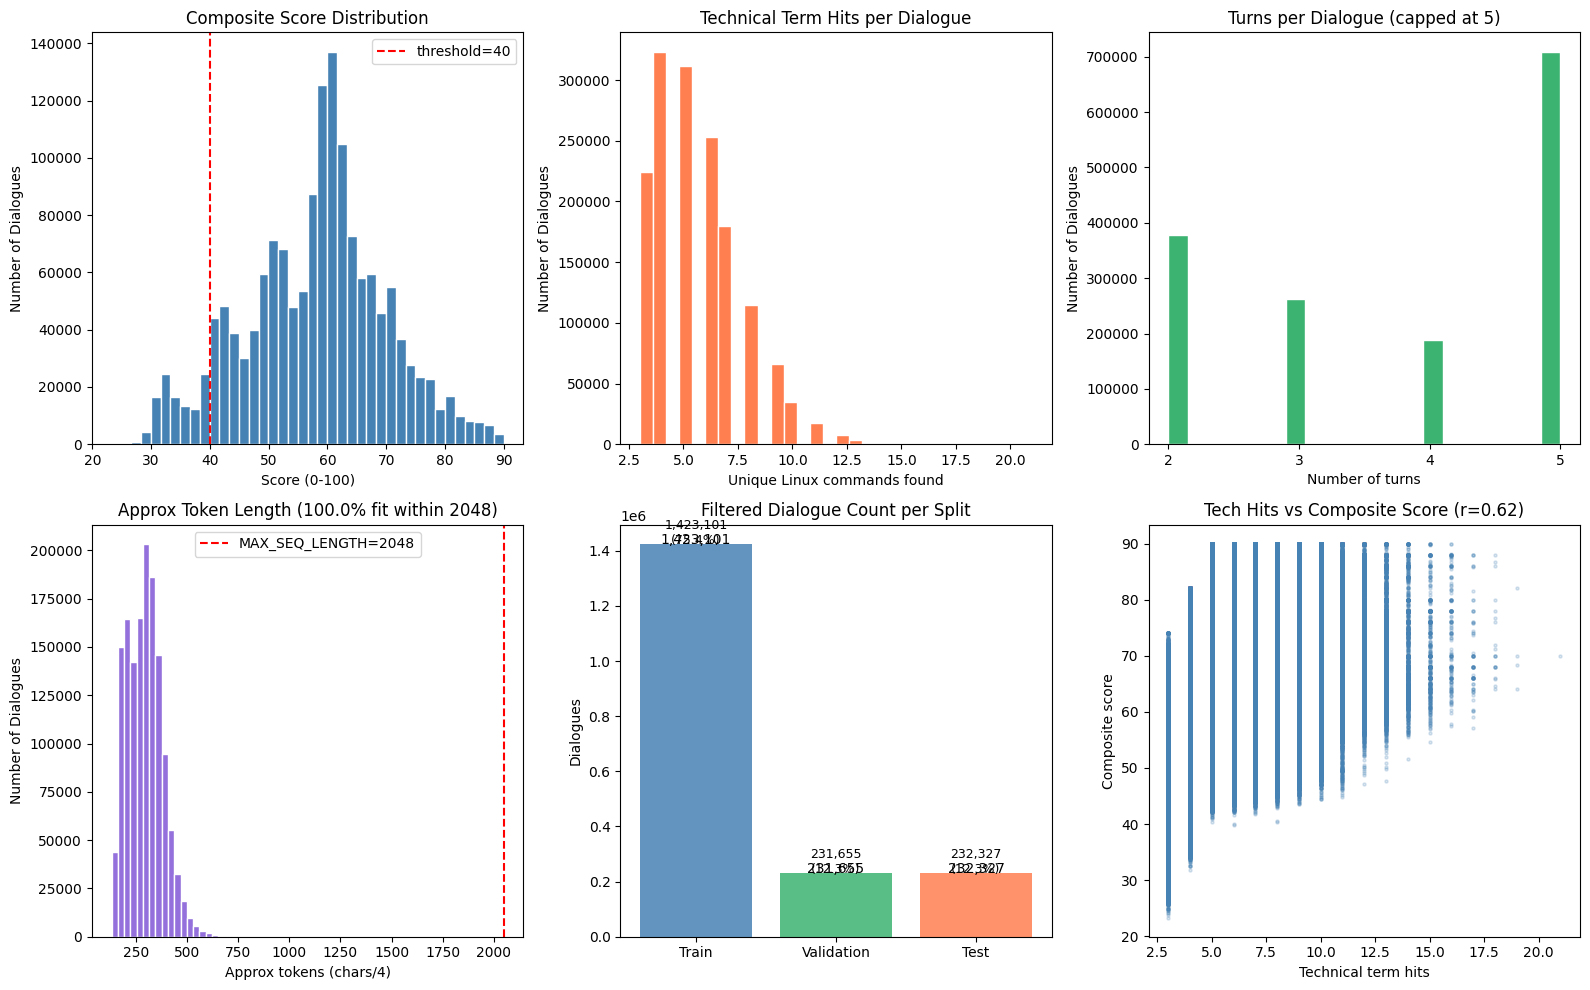

Figure saved: dialogue_quality_scores.png


In [12]:
# Visualize score distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
scores_df = train_scores_df

# Plot 1
# Composite Score Distribution
axes[0,0].hist(scores_df['composite_score'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(QUALITY_THRESHOLD, color='red', linestyle='--', label=f'threshold={QUALITY_THRESHOLD}')
axes[0,0].set_title('Composite Score Distribution')
axes[0,0].set_xlabel('Score (0-100)')
axes[0,0].legend()
axes[0,0].set_ylabel('Number of Dialogues')

# Plot 2
# Technical Term Hits per Dialogue
axes[0,1].hist(scores_df['tech_hits'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Technical Term Hits per Dialogue')
axes[0,1].set_xlabel('Unique Linux commands found')
axes[0,1].set_ylabel('Number of Dialogues')

# Plot 3
# Turns per Dialogue (capped at 5)
axes[0,2].hist(scores_df['num_turns'], bins=20, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Turns per Dialogue')
axes[0,2].set_xlabel('Number of turns')
axes[0,2].set_ylabel('Number of Dialogues')
axes[0,2].set_xticks([2, 3, 4, 5])
axes[0,2].set_title('Turns per Dialogue (capped at 5)')

# Plot 4
# Approximate Token Length
char_lens = [len(t) // 4 for t in train_filtered['full_text']]
axes[1,0].hist(char_lens, bins=40, color='mediumpurple', edgecolor='white')
axes[1,0].axvline(2048, color='red', linestyle='--', label='MAX_SEQ_LENGTH=2048')
axes[1,0].set_title('Approx Token Length (filtered dialogues)')
axes[1,0].set_xlabel('Approx tokens (chars/4)')
axes[1,0].legend()
axes[1,0].set_ylabel('Number of Dialogues') 
pct_fits = sum(1 for l in char_lens if l <= 2048) / len(char_lens) * 100
axes[1,0].set_title(f'Approx Token Length ({pct_fits:.1f}% fit within 2048)')

# Plot 5
# Filtered Dialogue Count per Split
splits = ['Train', 'Validation', 'Test']
counts = [len(train_filtered), len(valid_filtered), len(test_filtered)]
axes[1,1].bar(splits, counts, color=['steelblue','mediumseagreen','coral'], alpha=0.85)
for i, (s, c) in enumerate(zip(splits, counts)):
    axes[1,1].text(i, c + 50, f'{c:,}', ha='center', fontsize=10)
axes[1,1].set_title('Filtered Dialogue Count per Split')
axes[1,1].set_ylabel('Dialogues')
for i, (s, c) in enumerate(zip(splits, counts)):
    total = sum(counts)
    axes[1,1].text(i, c + 50, f'{c:,}\n({c/total*100:.1f}%)', 
                   ha='center', fontsize=9)

# Plot 6
# Tech Hits vs Composite Score
axes[1,2].scatter(scores_df['tech_hits'], scores_df['composite_score'],
                  alpha=0.2, s=5, color='steelblue')
axes[1,2].set_title('Tech Hits vs Composite Score')
axes[1,2].set_xlabel('Technical term hits')
axes[1,2].set_ylabel('Composite score')
corr = np.corrcoef(scores_df['tech_hits'], scores_df['composite_score'])[0,1]
axes[1,2].set_title(f'Tech Hits vs Composite Score (r={corr:.2f})')

plt.tight_layout()
plt.savefig('dialogue_quality_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: dialogue_quality_scores.png')

In [ ]:
##  Dataset Quality & Distribution Analysis — Key Observations

- **Composite Score Distribution (Plot 1)**
  - Approximately bell-shaped, centered around 55–60
  - Quality threshold (40) is appropriately placed
  - Majority of dialogues exceed threshold → strong dataset quality
  - Small low-score tail indicates effective filtering

- **Technical Term Hits (Plot 2)**
  - Most dialogues contain 3–5 Linux commands → healthy technical density
  - Sharp drop after ~7–8 hits → expected conversational behavior
  - Long tail up to ~20 hits → captures expert-level discussions

- **Turns per Dialogue (Plot 3)**
  - Values limited to 2–5 turns due to `MAX_TURNS=5` cap
  - Large spike at 5 turns indicates widespread truncation
  - Behavior is expected but potentially misleading visually
  - *Improvement:* clarify cap in title and fix x-axis ticks

- **Approx Token Length (Plot 4)**
  - Majority of dialogues fall within 200–400 tokens
  - Very few approach the 2048-token limit

- **Dataset Split Counts (Plot 5)**
  - Train: 1.42M, Validation: 211K, Test: 232K
  - Approximate ratio ~6:1:1 → appropriate and standard
  - Reflects post-filtering counts before sampling

- **Tech Hits vs Composite Score (Plot 6)**
  - Clear positive correlation → scoring captures technical relevance
  - Discrete vertical patterns reflect integer-valued tech hits
  - Variance within each level shows influence of other scoring factors

- **Overall Assessment**
  - Dataset is high-quality, well-filtered, and technically rich
  - Distributions align with expectations for Ubuntu IRC data

In [13]:
# Check approximate token lengths
# 1 token ≈ 4 characters — good enough to decide MAX_SEQ_LENGTH
sample_lens = [len(t) // 4 for t in train_filtered['full_text'].head(1000)]

print('Approximate token length stats (n=1000 from train):')
print(f'  Min    : {min(sample_lens)}')
print(f'  Median : {int(np.median(sample_lens))}')
print(f'  Mean   : {int(np.mean(sample_lens))}')
print(f'  95th % : {int(np.percentile(sample_lens, 95))}')
print(f'  99th % : {int(np.percentile(sample_lens, 99))}')
print(f'  Max    : {max(sample_lens)}')
pct = sum(1 for l in sample_lens if l <= 2048) / len(sample_lens) * 100
print(f'\n  {pct:.1f}% fit within 2048 tokens')

Approximate token length stats (n=1000 from train):
  Min    : 156
  Median : 341
  Mean   : 349
  95th % : 472
  99th % : 557
  Max    : 633

  100.0% fit within 2048 tokens


In [14]:
#  Random sample and saving to CSV
MAX_TRAIN = 30_000
MAX_VALID =  3_000
MAX_TEST  =    500

train_final = train_filtered.sample(
    n=min(MAX_TRAIN, len(train_filtered)), random_state=42
).reset_index(drop=True)

valid_final = valid_filtered.sample(
    n=min(MAX_VALID, len(valid_filtered)), random_state=42
).reset_index(drop=True)

test_final = test_filtered.sample(
    n=min(MAX_TEST, len(test_filtered)), random_state=42
).reset_index(drop=True)

# Save to CSV 
train_final.to_csv('train_ready.csv', index=False)
valid_final.to_csv('valid_ready.csv', index=False)
test_final.to_csv('test_ready.csv',  index=False)

print('Files saved:')
print(f'  train_ready.csv : {len(train_final):,} dialogues  ({os.path.getsize("train_ready.csv")/1e6:.1f} MB)')
print(f'  valid_ready.csv : {len(valid_final):,} dialogues  ({os.path.getsize("valid_ready.csv")/1e6:.1f} MB)')
print(f'  test_ready.csv  : {len(test_final):,} dialogues  ({os.path.getsize("test_ready.csv")/1e6:.1f} MB)')
print(f'\nSample dialogue:\n{train_final["full_text"].iloc[0][:400]}')

Files saved:
  train_ready.csv : 30,000 dialogues  (35.3 MB)
  valid_ready.csv : 3,000 dialogues  (2.8 MB)
  test_ready.csv  : 500 dialogues  (0.5 MB)

Sample dialogue:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledgeable Ubuntu and Linux technical support assistant. Given a conversation history, provide a clear, accurate, and helpful response that resolves the technical issue. Use correct Linux commands where relevant.<|eot_id|><|start_header_id|>user<|end_header_id|>

DUse alt+click to move it<|eot_id|><|start_header_id|>assistan


In [15]:
# Verify saved files are correct before closing
for fname in ['train_ready.csv', 'valid_ready.csv', 'test_ready.csv']:
    df = pd.read_csv(fname)
    nulls = df['full_text'].isna().sum()
    print(f'{fname:<20} : {len(df):,} rows  |  nulls: {nulls}  |  sample: {df["full_text"].iloc[0][:80]}...')


train_ready.csv      : 30,000 rows  |  nulls: 0  |  sample: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledge...
valid_ready.csv      : 3,000 rows  |  nulls: 0  |  sample: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledge...
test_ready.csv       : 500 rows  |  nulls: 0  |  sample: <|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a knowledge...
